In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
X, y = make_regression(n_samples=4, n_features=1, n_targets=1, noise=80, n_informative=1, random_state=2)

In [3]:
X, y

(array([[-0.05626683],
        [ 1.64027081],
        [-0.41675785],
        [-2.1361961 ]]),
 array([ -51.74312484,  140.43888756, -103.47559951, -209.87935566]))

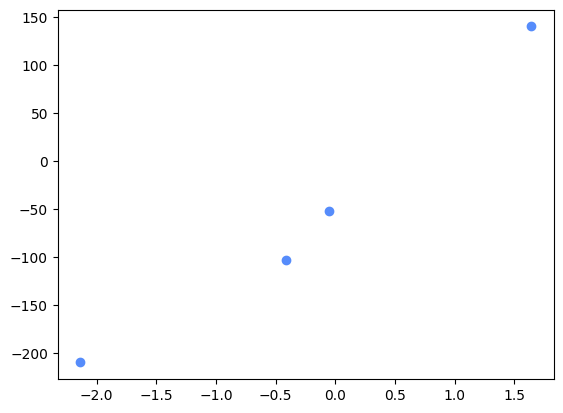

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [5]:
# Lets apply OLS
from sklearn.linear_model import LinearRegression

In [6]:
model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print('Coef', model.coef_)
print('Intercept', model.intercept_)

Coef [93.15173497]
Intercept -33.59995559847465


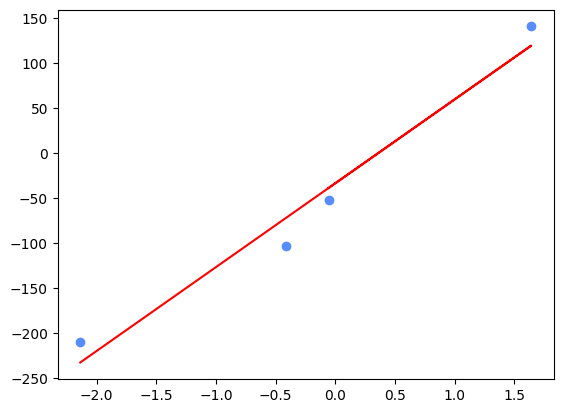

In [8]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red')

In [9]:
# Let's apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 100).reshape(4)

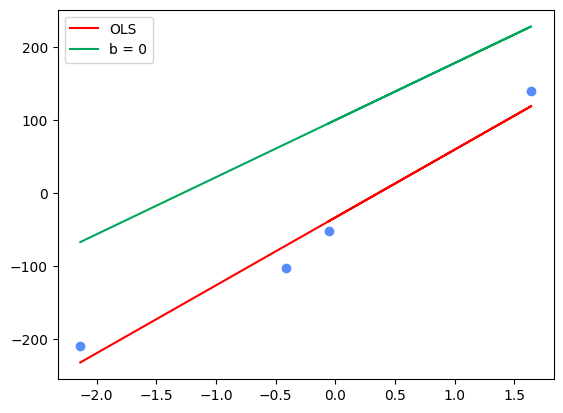

In [10]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

In [26]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(297.48392586351173)

In [27]:
# Let's take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(29.748392586351173)

In [28]:
# Calculating the new intercept
b = b - step_size
b

np.float64(-29.748392586351173)

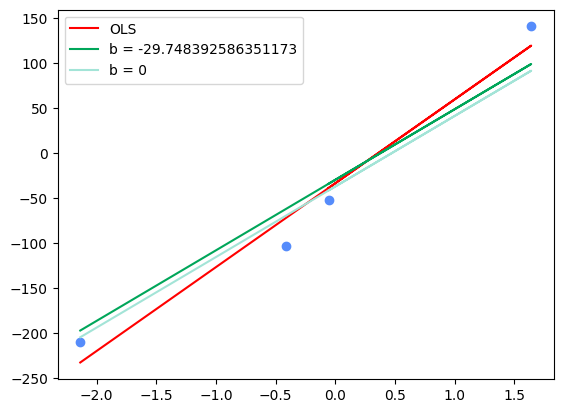

In [29]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [30]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(59.49678517270233)

In [31]:
step_size = loss_slope*lr
step_size

np.float64(5.949678517270233)

In [32]:
b = b - step_size
b

np.float64(-35.69807110362141)

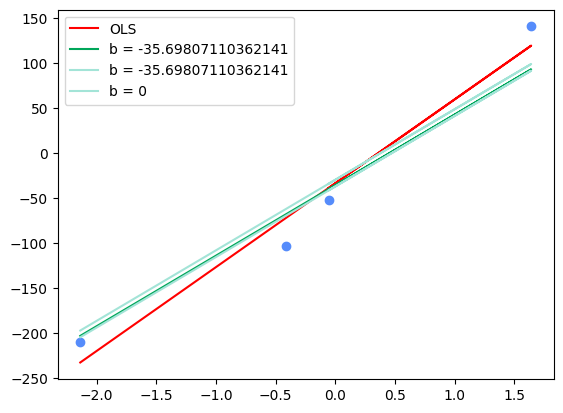

In [33]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [34]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope


np.float64(11.899357034540444)

In [35]:
step_size = loss_slope*lr
step_size

np.float64(1.1899357034540443)

In [36]:
b = b - step_size
b

np.float64(-36.888006807075456)

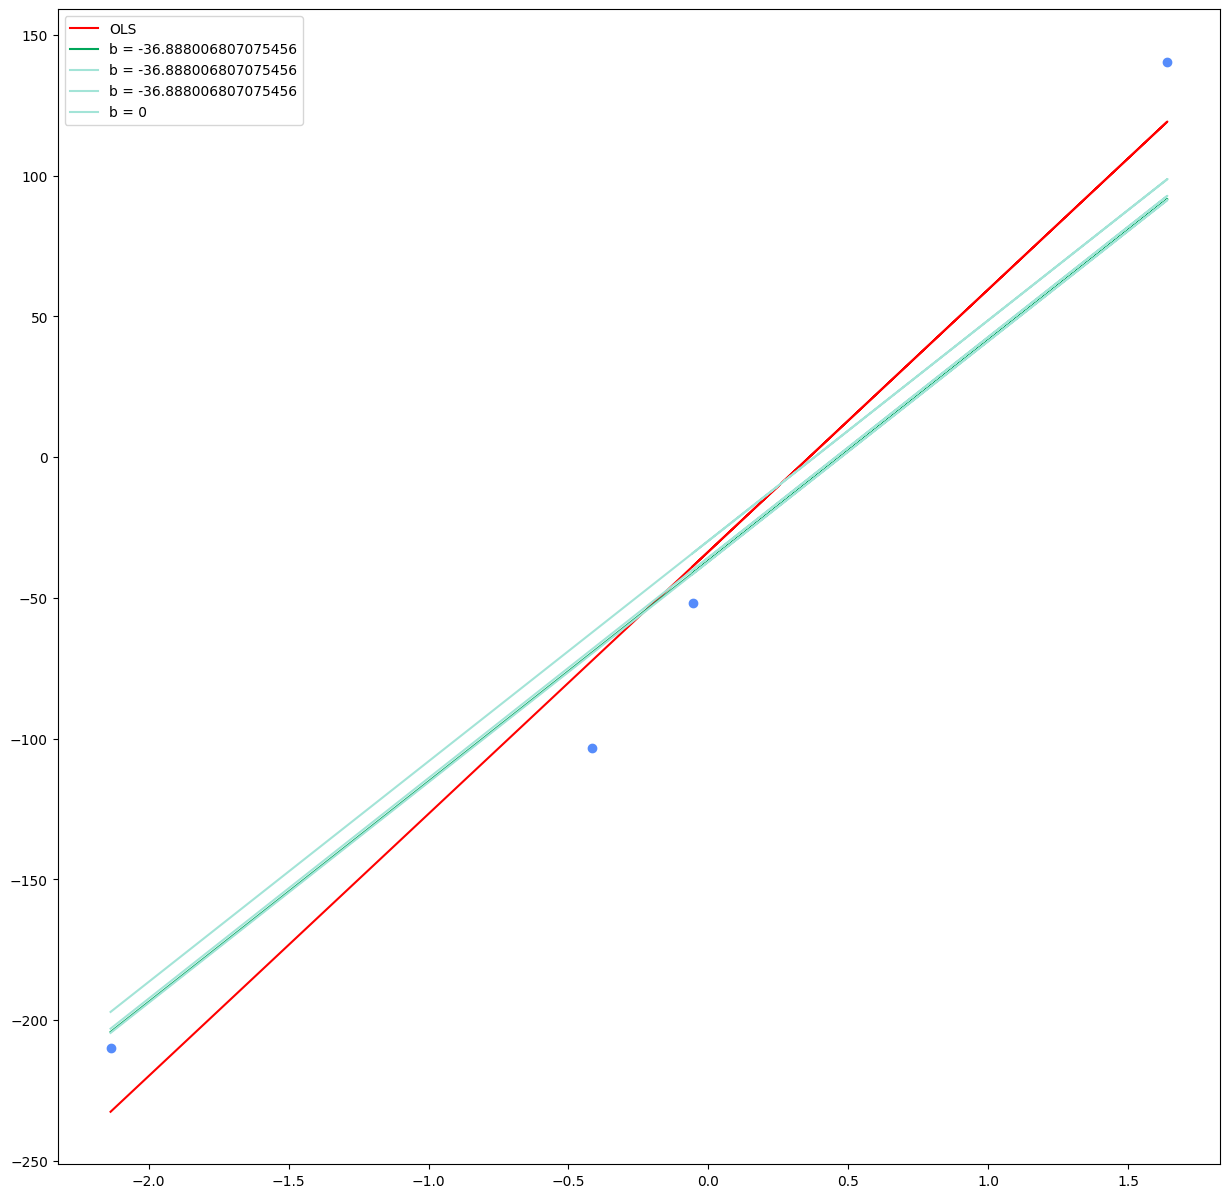

In [37]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

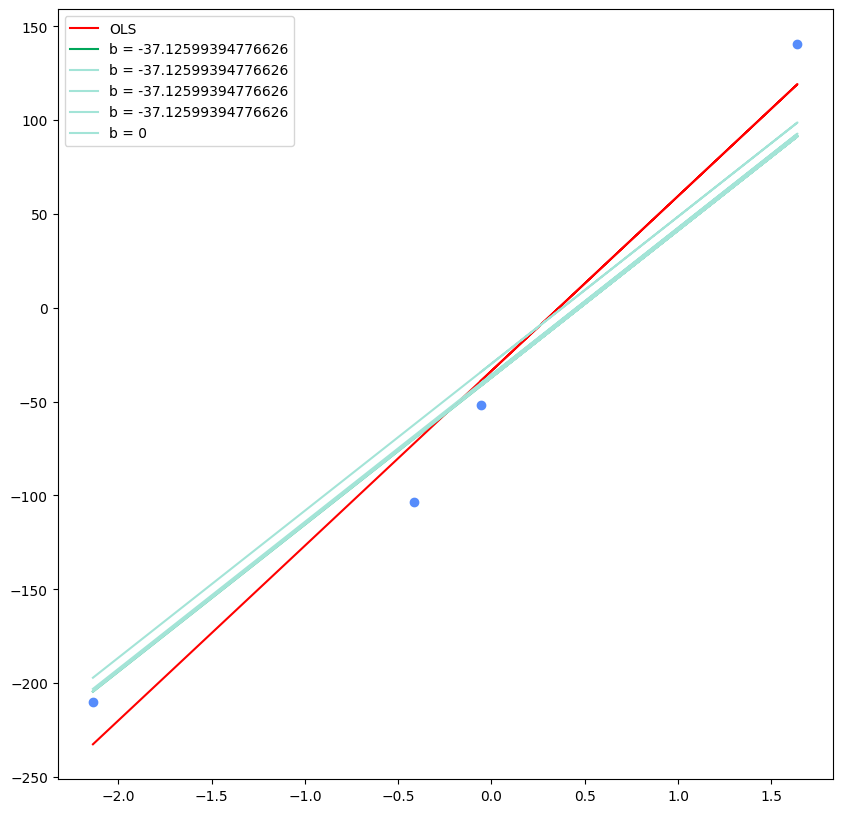

In [38]:
# Iteration 4
loss_slope = -2 * np.sum(y - m*X.ravel() - b)

step_size = loss_slope*lr

b = b - step_size

y_pred4 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(10,10))
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred4,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred3,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

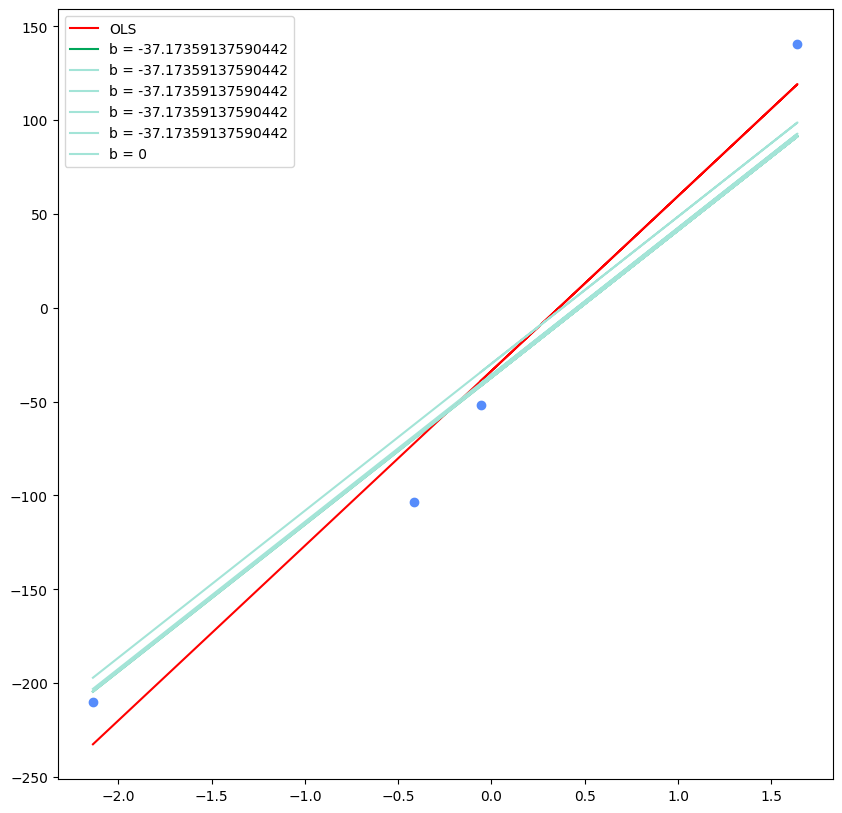

In [39]:
# Iteration 5
# Iteration 5
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
step_size = loss_slope*lr
b = b - step_size

y_pred5 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(10,10))
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred5,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred4,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred3,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

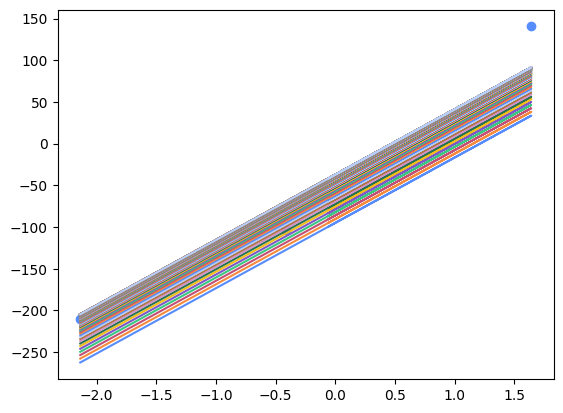

In [25]:
# Using loop
b = -100
m = 78.35
lr = 0.01
epochs = 100

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - b)
    step_size = loss_slope*lr
    b = b - step_size

    y_pred = m * X + b

    plt.plot(X,y_pred)

plt.scatter(X,y)
